# 4.2. The Image Classification Dataset

The notebooks in this directory depend on the following software versions.

1. MindSpore 2.8.0
1. CANN 8.5.0

Follow the official instructions to install CANN 8.5.0, then install MindSpore 2.8.0 and dependent packages with Pip.

In [1]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Now initialize MindSpore to use the Ascend 310B1 chip on our OrangePi AIpro \(20T\) development board and run a sanity check.

In [2]:
import mindspore
mindspore.set_device(device_target='Ascend', device_id=0)
mindspore.run_check()

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


Ignore warning messages except for those starting with `[ERROR]` or `[CRITICAL]` in which case consult the Ascend forum. The expected output is given below.

```text
MindSpore version: 2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!
```

## 4.2.1. Loading the Dataset

Create the folder `data/fashion/` and download the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset from the upstream GitHub repository. It's a replacement of the original MNIST dataset for improved benchmarking and evaluation of image classification algorithms in machine learning.

In [3]:
import os

dataset_dir = 'data/fashion/'
os.makedirs(dataset_dir, exist_ok=True)

In [4]:
import gzip
import urllib.request

X_train_url = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-images-idx3-ubyte.gz'
y_train_url = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-labels-idx1-ubyte.gz'
X_test_url = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-images-idx3-ubyte.gz'
y_test_url = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-labels-idx1-ubyte.gz'

X_train_path = os.path.join(dataset_dir, 'train-images-idx3-ubyte')
y_train_path = os.path.join(dataset_dir, 'train-labels-idx1-ubyte')
X_test_path = os.path.join(dataset_dir, 't10k-images-idx3-ubyte')
y_test_path = os.path.join(dataset_dir, 't10k-labels-idx1-ubyte')

with urllib.request.urlopen(X_train_url) as response:
    with open(X_train_path, 'wb') as out_file:
        data_gzip = response.read()
        data = gzip.decompress(data_gzip)
        out_file.write(data)

with urllib.request.urlopen(y_train_url) as response:
    with open(y_train_path, 'wb') as out_file:
        data_gzip = response.read()
        data = gzip.decompress(data_gzip)
        out_file.write(data)

with urllib.request.urlopen(X_test_url) as response:
    with open(X_test_path, 'wb') as out_file:
        data_gzip = response.read()
        data = gzip.decompress(data_gzip)
        out_file.write(data)

with urllib.request.urlopen(y_test_url) as response:
    with open(y_test_path, 'wb') as out_file:
        data_gzip = response.read()
        data = gzip.decompress(data_gzip)
        out_file.write(data)

Now we can load the dataset for MindSpore. MindSpore 2.8.0 provides the [`mindspore.dataset.FashionMnistDataset`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/dataset/mindspore.dataset.FashionMnistDataset.html) class for this purpose with the below parameters.

1. `dataset_dir`: directory path to the Fashion MNIST dataset, e.g. `data/fashion/`
1. `usage`: whether to load the training \(`'train'`\) or validation \(`'test'`\) dataset, or both \(`'all'`\)
1. `shuffle`: whether to shuffle the dataset

In [5]:
import mindspore.dataset as ds

train_ds = ds.FashionMnistDataset(dataset_dir=dataset_dir, usage='train', shuffle=True)
test_ds = ds.FashionMnistDataset(dataset_dir=dataset_dir, usage='test', shuffle=True)

Define an utility function `transform_and_batch` to apply the transformations to both training and validation sets as described below, then create batches of $2^9=512$ samples per batch.

1. Resize each image to $32 \times 32$ pixels
1. Reshape each image from `(32, 32, 1)` to `(1, 32, 32)`. The last dimension before re-shaping is the single grayscale channel for each pixel, with values in integer range $[0, 255]$
1. Normalize the value of each grayscale pixel from integer in range $[0, 255]$ to float in range $[0, 1]$

In [6]:
import mindspore.dataset.vision as vision

resize_to_32x32 = vision.Resize(size=(32, 32))
hwc2chw = vision.HWC2CHW()
normalize_channels = vision.Rescale(rescale=1/255, shift=0)

def transform_and_batch(dataset):
    dataset = dataset.map(operations=[resize_to_32x32, hwc2chw, normalize_channels], input_columns='image')
    dataset = dataset.batch(batch_size=512, drop_remainder=False)
    return dataset

Transform both training and validation sets and verify the resulting datasets have the correct shape and content.

In [7]:
train_ds = transform_and_batch(dataset=train_ds)
test_ds = transform_and_batch(dataset=test_ds)
X_train_sample = None

for batch_idx, (X_batch, y_batch) in enumerate(train_ds.create_tuple_iterator()):
    print(f'Training set batch #{batch_idx}: images with shape {X_batch.shape}, labels with shape {y_batch.shape}')
    if batch_idx == 0:
        X_train_sample = X_batch[0]

for batch_idx, (X_batch, y_batch) in enumerate(test_ds.create_tuple_iterator()):
    print(f'Validation set batch #{batch_idx}: images with shape {X_batch.shape}, labels with shape {y_batch.shape}')

X_train_sample.shape, X_train_sample.min(), X_train_sample.max()

Training set batch #0: images with shape (512, 1, 32, 32), labels with shape (512,)
Training set batch #1: images with shape (512, 1, 32, 32), labels with shape (512,)
Training set batch #2: images with shape (512, 1, 32, 32), labels with shape (512,)
Training set batch #3: images with shape (512, 1, 32, 32), labels with shape (512,)
Training set batch #4: images with shape (512, 1, 32, 32), labels with shape (512,)
Training set batch #5: images with shape (512, 1, 32, 32), labels with shape (512,)
Training set batch #6: images with shape (512, 1, 32, 32), labels with shape (512,)
Training set batch #7: images with shape (512, 1, 32, 32), labels with shape (512,)
Training set batch #8: images with shape (512, 1, 32, 32), labels with shape (512,)
Training set batch #9: images with shape (512, 1, 32, 32), labels with shape (512,)
Training set batch #10: images with shape (512, 1, 32, 32), labels with shape (512,)
Training set batch #11: images with shape (512, 1, 32, 32), labels with sha

((1, 32, 32),
 Tensor(shape=[], dtype=Float32, value= 0),
 Tensor(shape=[], dtype=Float32, value= 0.768628))

Define an utility function mapping numeric labels representing categories to their human-readable names. This will come in handy later.

In [8]:
LABELS = [
    't-shirt',
    'trouser',
    'pullover',
    'dress',
    'coat',
    'sandal',
    'shirt',
    'sneaker',
    'bag',
    'ankle boot'
]

def text_labels(indices):
    return [LABELS[int(i)] for i in indices]

text_labels(list(range(10))), text_labels(list(reversed(range(10))))

(['t-shirt',
  'trouser',
  'pullover',
  'dress',
  'coat',
  'sandal',
  'shirt',
  'sneaker',
  'bag',
  'ankle boot'],
 ['ankle boot',
  'bag',
  'sneaker',
  'shirt',
  'sandal',
  'coat',
  'dress',
  'pullover',
  'trouser',
  't-shirt'])

## 4.2.2. Reading a Minibatch

Let's see how long it takes to load the entire dataset by looping through all minibatches.

In [9]:
import time

start = time.time()

for _, (_, _) in enumerate(train_ds.create_tuple_iterator()):
    continue
for _, (_, _) in enumerate(test_ds.create_tuple_iterator()):
    continue

end = time.time()
end - start

4.253173112869263

It takes about 4 to 5 seconds which is negligible compared to the training process.

## 4.2.3. Visualization

Let's visualize the first 10 images in our first training minibatch with Matplotlib.

In [10]:
X_batch, y_batch = next(train_ds.create_tuple_iterator())
X_batch, y_batch = X_batch[:10].asnumpy(), y_batch[:10].asnumpy()
X_batch, y_batch

(array([[[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]],
 
 
        [[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]],
 
 
        [[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]],
 
 
        ...,
 
 
        [[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
   

In [11]:
%pip install matplotlib==3.10.8


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


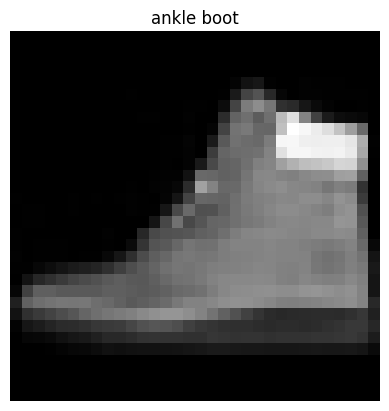

In [12]:
import matplotlib.pyplot as plt
import numpy as np

X_sample, y_sample = X_batch[0], y_batch[0]
plt.title(LABELS[y_sample.item()])
plt.imshow(np.squeeze(X_sample), cmap='gray')
plt.axis('off')
plt.show()

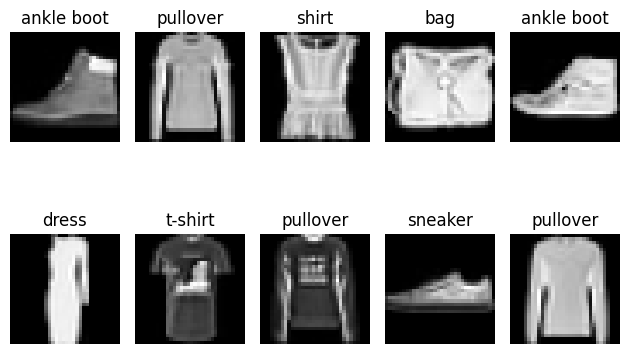

In [13]:
fig, axes = plt.subplots(2, 5)
for axis_idx, axis in enumerate(axes.flatten()):
    axis.set_title(LABELS[y_batch[axis_idx].item()])
    axis.imshow(np.squeeze(X_batch[axis_idx]), cmap='gray')
    axis.axis('off')
fig.tight_layout()
fig.show()

## 4.2.4. Summary

Now that we know how to load the Fashion MNIST dataset and understand its structure, we are now ready to work with it for linear classification.